# Firm characteristics: a neural network under the objective that already failed

[`06_gbm`](06_gbm.ipynb) varied the loss function on a fixed target and found that what the fit
is asked to minimize separates the grid while capacity barely moves it. This notebook fits a
neural network built for tabular data to the same targets, the same characteristics and the same
folds - and it cannot repeat that experiment, because the shared TabM runner minimizes **squared
error** on a regression target and cross-entropy on a classification one, and neither is a
declared axis of the menu. The three configurations differ in capacity alone.

So the comparison this notebook can make is the other one. Holding the objective fixed at the
loss `06_gbm` identified as the poorly matched one, it varies:

- **capacity**, across three presets that raise hidden width and ensemble membership together -
  `tabm_s` at 64 units and 4 members, `tabm_m` at 128 and 8, `tabm_l` at 256 and 16;
- **the amount of training**, because every configuration publishes a prediction set at each of
  its declared epoch checkpoints rather than at the end of training only;
- **the target**, because all three declared labels are fitted in one run - `fwd_ret_1m`,
  its winsorized variant `fwd_ret_1m_win`, and the classification variant `fwd_class_1m`, whose
  cross-entropy objective has no stake in the size of a tail return at all.

**What TabM is.** A conventional deep ensemble trains several independent networks and averages
them, which costs several networks. TabM keeps one shared backbone and gives each ensemble
member a small adapter of its own - one learned scaling vector, applied to the backbone's output
rather than inside it, so a member costs a row of parameters rather than a matrix. Each member
also carries its own output head. The members train together in one forward pass and diverge
only through those vectors, and averaging them cancels the part of each member's error that its
own scaling made independent. `n_members` is how many adapters there are, and it is
the axis that separates the three presets alongside hidden width.

**Learning objectives**

- Read a capacity grid whose objective is fixed by the runner rather than declared by the menu.
- Use the epoch checkpoint as part of a configuration's identity rather than as something
  resolved away by a validation metric.
- See what a nonlinear model extracts from a monthly cross-section that a linear grid did not.

**Book reference**: Chapter 12, Section 12.3 (Deep learning alternatives for tabular data).
Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run log this notebook
writes into.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_evaluation`](04_evaluation.ipynb), [`05_linear`](05_linear.ipynb), [`06_gbm`](06_gbm.ipynb).

**What it writes**: one training run per configuration and label, and one complete validation
prediction set per configuration, label and epoch checkpoint, in `run_log/registry.db` and under
`run_log/training/` and `run_log/predictions/`, grouped under a named population.
[`11_backtest`](11_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here**, and the checkpoint is part of what it selects.

In [1]:
"""Fit the declared firm-characteristics TabM population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl
import yaml
from plotly.subplots import make_subplots

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    plan_models,
    planned_model_plan,
    primary_label,
    run_model_population,
    supersedes_for_run,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = "cc48431f8869"

In [3]:
study = open_study(
    "us_firm_characteristics", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which labels, which models, and on what hardware

Every label whose training menu declares `tabular_dl:` is fitted in this run, and all three do.
`fwd_ret_1m` is the primary one, the total return over the month after the decision date;
`fwd_ret_1m_win` is the same return with each month's cross-section clipped at its own tails;
`fwd_class_1m` turns that return into a class. Each carries its own menu at
`config/training/{label}.yaml`.

In [4]:
declared_labels(study, "tabular_dl")

('fwd_class_1m', 'fwd_ret_1m', 'fwd_ret_1m_win')

The three presets live in `case_studies/config/tabm/` and raise hidden width and ensemble
membership together, at a fixed dropout, a fixed batch size and a fixed epoch budget. Holding
the training length fixed is what makes the grid a capacity comparison rather than a
capacity-and-duration one, and the checkpoint dimension below is how the duration is examined
separately.

In [5]:
configs = load_model_configs(
    study,
    "tabular_dl",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""tabular_dl""","""fwd_class_1m""","""tabm_s""","""""","""dropout=0.1, hidden_dim=64, n_…"
"""tabular_dl""","""fwd_class_1m""","""tabm_m""","""""","""dropout=0.1, hidden_dim=128, n…"
"""tabular_dl""","""fwd_class_1m""","""tabm_l""","""""","""dropout=0.1, hidden_dim=256, n…"
"""tabular_dl""","""fwd_ret_1m""","""tabm_s""","""""","""dropout=0.1, hidden_dim=64, n_…"
"""tabular_dl""","""fwd_ret_1m""","""tabm_m""","""""","""dropout=0.1, hidden_dim=128, n…"
"""tabular_dl""","""fwd_ret_1m""","""tabm_l""","""""","""dropout=0.1, hidden_dim=256, n…"
"""tabular_dl""","""fwd_ret_1m_win""","""tabm_s""","""""","""dropout=0.1, hidden_dim=64, n_…"
"""tabular_dl""","""fwd_ret_1m_win""","""tabm_m""","""""","""dropout=0.1, hidden_dim=128, n…"
"""tabular_dl""","""fwd_ret_1m_win""","""tabm_l""","""""","""dropout=0.1, hidden_dim=256, n…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name: on a fresh workspace it would otherwise register an
incomplete snapshot under the canonical one, and where the full population already exists the
registry refuses it. The comparison is over `(label, config_name)` pairs rather than row counts,
because a subset can match the canonical population on height while declaring different members.

In [6]:
if narrows_declared_catalog(study, "tabular_dl", configs) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the declared label-configuration pairs, so it cannot "
        "publish the canonical population; pass POPULATION_NAME to give it its own"
    )

Two execution settings are declared in `config/setup.yaml` under `modeling.tabular_dl`, and both
are part of a training identity rather than provenance beside it. A network's arithmetic depends
on the device it runs on and on how many host threads reduce a batch, so a CUDA result and a CPU
result of the same configuration are different computations and get different hashes. The runner
refuses a device the machine does not have rather than falling back to one it does: silently
substituting the fallback would publish a differently computed result under a declaration that
says otherwise. A reader without an NVIDIA card sets `device: cpu` here and gets their own
identities, which is the honest answer rather than a matching one.

In [7]:
setup = yaml.safe_load(
    (get_case_study_dir("us_firm_characteristics") / "config" / "setup.yaml").read_text()
)
execution_settings = setup["modeling"]["tabular_dl"]
overrides = {
    "device": str(execution_settings["device"]),
    "num_threads": int(execution_settings["num_threads"]),
}
overrides

{'device': 'cuda', 'num_threads': 8}

## 2. Binding the declarations to the data

Planning reads the label and feature files, computes the fold boundaries from the walk-forward
parameters in `config/setup.yaml`, works out the exact rows each fit must predict, and derives
every training and prediction identity - without fitting anything and without holding the
prepared panel for each configuration at once. Configurations that read the same label share one
materialization of it, so the panel is loaded once per label rather than once per configuration.

Four things to check in the plan:

- **`feature_count` and `eligible_rows` agree across every row of a label.** A row that differs
  is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  [`04_evaluation`](04_evaluation.ipynb) established.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is the number of training states each configuration will publish predictions
  for.** It comes from the preset's epoch budget and checkpoint interval, and multiplying it by
  the number of rows gives the number of candidate models this notebook is about to create.

In [8]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides=overrides,
    preview_reductions=PREVIEW_REDUCTIONS,
    notebook="07_tabular_dl",
)
plan = plan_models(study, requests=requests)

planned_model_plan(plan).select(
    "label",
    "config_name",
    "task",
    "feature_count",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,task,feature_count,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,str,i64,i64,i64,i64,str,str
"""fwd_class_1m""","""tabm_l""","""classification""",57,252008,10,8,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_class_1m""","""tabm_m""","""classification""",57,252008,10,8,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_class_1m""","""tabm_s""","""classification""",57,252008,10,8,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_ret_1m""","""tabm_l""","""regression""",57,252008,10,8,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_ret_1m""","""tabm_m""","""regression""",57,252008,10,8,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_ret_1m""","""tabm_s""","""regression""",57,252008,10,8,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_ret_1m_win""","""tabm_l""","""regression""",57,252008,10,8,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_ret_1m_win""","""tabm_m""","""regression""",57,252008,10,8,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_ret_1m_win""","""tabm_s""","""regression""",57,252008,10,8,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""


The plan is also the point at which a short population is visible. A run that fitted fewer
label-configuration pairs than the menu declares would still print an IC table and still
register its rows; what it would not do is announce the gap. Comparing the planned members
against the frame loaded above catches it here, before anything is fitted.

In [9]:
planned_pairs = {(member.label, member.config_name) for member in plan.members}
requested_pairs = set(zip(configs["label"], configs["config_name"], strict=True))
if planned_pairs != requested_pairs:
    raise RuntimeError(
        "the plan does not match the loaded TabM menu; "
        f"missing {sorted(requested_pairs - planned_pairs)}, "
        f"unexpected {sorted(planned_pairs - requested_pairs)}"
    )
print(f"{len(requested_pairs)} label-configuration pairs")
print(f"{len(plan.expected_training_hashes)} training identities")
print(f"{len(plan.expected_prediction_hashes)} validation prediction sets")

9 label-configuration pairs
9 training identities
72 validation prediction sets


## 3. Fitting the population

`run_model_population` runs every planned request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fits a median imputer and a standardizer on those rows and applies them to the fold's
   validation rows - a network needs a complete, comparably scaled design matrix, unlike the
   trees in [`06_gbm`](06_gbm.ipynb) which route a missing value down their own branch,
3. trains the shared backbone and every member's adapter for the declared number of epochs,
   saving the fitted state at each checkpoint on the way,
4. predicts the fold's validation rows from each saved state.

Step 4 is what makes one fit produce many results. Fold predictions are concatenated into one
series per checkpoint covering the whole validation period, and each becomes its own registered
prediction set with its own identity. Nothing here chooses among them.

**This notebook passes the plan rather than resolved requests, and that decides how the fitting
is ordered.** There are two paths through `run_model_population`. Passing the plan hands the
still-unresolved requests to the TabM batch runner, which groups the configurations reading the
same label and prepares that label's folds once for all of them. Passing resolved requests
instead fits one configuration at a time, each preparing its own folds - which is what
[`05_linear`](05_linear.ipynb) and [`06_gbm`](06_gbm.ipynb) do, and they say so there.

The trade is what the plan table above could show. Resolving first would have added
`eligible_entities`, which needs the eligibility keys themselves; planning derives the same
identities from the specification and cannot. Nine configurations holding nine prepared copies
of a panel this size is the wrong side of that trade, and `eligible_rows` moves whenever the
universe does, so the check the column existed for is still made.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [10]:
population_name = POPULATION_NAME or "us_firm_characteristics-tabular_dl-validation-v1"
# The declared hash is only meaningful where a generation of this name already exists. A preview
# run, a reader's first canonical run against an empty `run_log/`, and a run under a caller-chosen
# `POPULATION_NAME` are all refused by `OfficialPopulation.create` if it is passed anyway. The
# resolution lives in shared code so no notebook branches on the tier.
supersedes = supersedes_for_run(
    study,
    population_name=population_name,
    declared=SUPERSEDES_POPULATION,
    execution_tier=EXECUTION_TIER,
)
execution, population = run_model_population(
    study, plan, population_name=population_name, supersedes=supersedes
)

# The runner's paths do not all record the same diagnostics, so the split below is printed only
# when every run recorded it. A run that prepared folds - fitted or resolved, batch or single
# request - carries `fitted_folds` and `reused_folds`. A configuration served whole from the
# registry carries neither, because it prepared no folds and so has none to count, and neither
# does the latent-factor runner, which records nothing at all. Indexing the keys raises
# `KeyError` on those, and defaulting them to zero is worse: it reports every fold as served from
# the registry, which is the opposite of what nothing-recorded means, and it does so in a number
# a reader cannot tell from a measurement.
with_folds = [item for item in execution.diagnostics if "fitted_folds" in item]
print(f"{len(execution.runs)} configurations, fitted or served from the registry")
if with_folds and len(with_folds) == len(execution.diagnostics):
    fitted = sum(len(item["fitted_folds"]) for item in with_folds)
    served = sum(len(item["reused_folds"]) for item in with_folds)
    print(f"folds fitted: {fitted}, folds served from the registry: {served}")
else:
    print(
        f"{len(with_folds)} of {len(execution.diagnostics)} runs recorded fold counts, "
        "so the fitted-against-served split is not reported"
    )
print(f"population {population.name}: {len(population.members)} prediction sets")

9 configurations, fitted or served from the registry
0 of 9 runs recorded fold counts, so the fitted-against-served split is not reported
population us_firm_characteristics-tabular_dl-validation-v1: 72 prediction sets


On a second run every configuration is served from the registry. Each identity is re-derived
from the inputs, the registry already holds the matching rows, and the runner returns the
stored result rather than fitting again - so re-running this notebook unchanged costs the time
it takes to read the data rather than the time it took to fit.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("us_firm_characteristics", workspace="~/ml4t-experiments")
configs = load_model_configs(study, "tabular_dl", labels=["fwd_ret_1m"], config_names=["tabm_s"])
requests = model_requests(study, configs, overrides={"device": "cpu", "num_threads": 8})
plan = plan_models(study, requests=requests)
execution, population = run_model_population(study, plan, population_name="my-tabm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/tabm/tabm_xl.yaml` and list `tabm_xl` under `tabular_dl:` in the label's
menu. Editing an existing preset changes that configuration's identity, so its result registers
as a new row beside the old one rather than replacing it - and that includes `n_epochs` and
`checkpoint_interval`, which decide the checkpoint surface as much as the architecture does.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per label, configuration and epoch checkpoint. `ic_mean` is the **information
coefficient**: in each validation month, rank the firms by the model's prediction, rank them by
the return they went on to earn, correlate the two rankings, and average that monthly
correlation over the validation period.

**Every count and every aggregate below is keyed on `(label, config_name)`, not on the
configuration name alone.** The three presets are declared by all three labels, so grouping on
the name would average a configuration's result across the targets it appears in and concatenate
their learning curves into one line.

The published catalog is checked against the population planned before fitting, rather than
against its own row count: a run that lost a member would otherwise report a shorter table and
nothing else.

In [11]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "task",
    "complete",
    "checkpoint_kind",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "auc_mean_daily",
    "direction_label",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort(["label", "config_name", "checkpoint_value"])

if set(catalog.get_column("prediction_hash")) != set(plan.expected_prediction_hashes):
    raise RuntimeError("the published catalog differs from the population planned before fitting")
if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("a partial TabM checkpoint cannot pass to backtesting")
if catalog.select("label", "config_name", "checkpoint_value").n_unique() != catalog.height:
    raise RuntimeError("each label, configuration and checkpoint must identify one prediction set")
if catalog.get_column("checkpoint_value").null_count():
    raise RuntimeError("every TabM prediction must name the epoch it was taken at")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels by
# whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
pairs = catalog.select("label", "config_name").unique().height
print(f"{catalog.height} candidate models: {pairs} label-configuration pairs")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each, on {len(panel_labels)} labels")
catalog.select(
    "label",
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(15)

72 candidate models: 9 label-configuration pairs
at 8 checkpoints each, on 3 labels


label,config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,str,i64,f64,f64,f64,bool
"""fwd_class_1m""","""tabm_l""",25,0.06744,0.026207,110.0,true
"""fwd_class_1m""","""tabm_l""",50,0.049608,0.016413,110.0,true
"""fwd_class_1m""","""tabm_l""",75,0.042326,0.015507,110.0,true
"""fwd_class_1m""","""tabm_l""",100,0.038546,0.013359,110.0,true
"""fwd_class_1m""","""tabm_l""",125,0.03486,0.011758,110.0,true
…,…,…,…,…,…,…
"""fwd_class_1m""","""tabm_m""",75,0.055793,0.019875,110.0,true
"""fwd_class_1m""","""tabm_m""",100,0.051714,0.015398,110.0,true
"""fwd_class_1m""","""tabm_m""",125,0.051135,0.015706,110.0,true


### The same three presets, on each target

The characteristics and the folds are identical throughout, and all three labels declare the
same three presets, so between these rows the only thing that changes is what is being predicted
and - for the classification target alone - which loss the runner applies to it.

`ic_mean` is defined for all three, which is what puts them on one axis. `auc_monthly` can be
too, and `auc_scored_against` says what it was scored against: `fwd_class_1m` scores its own
label and leaves that column null, while `fwd_ret_1m` has no classes of its own and is scored as
a ranking signal against `fwd_class_1m`, the declared direction sibling of the same forward
month. Those two rows are therefore comparable on that one number. `fwd_ret_1m_win` declares no
sibling and carries no AUC; null there means not computed, not zero.

In [12]:
by_label = (
    catalog.filter("full_coverage")
    .group_by("label")
    .agg(
        task=pl.col("task").first(),
        configurations=pl.col("config_name").n_unique(),
        candidates=pl.len(),
        scored_months=pl.col("ic_n_days").max(),
        best_ic=pl.col("ic_mean").max(),
        worst_ic=pl.col("ic_mean").min(),
        best_auc_monthly=pl.col("auc_mean_daily").max(),
        auc_scored_against=pl.col("direction_label").drop_nulls().first(),
    )
    .sort("best_ic", descending=True)
)
by_label

label,task,configurations,candidates,scored_months,best_ic,worst_ic,best_auc_monthly,auc_scored_against
str,str,u32,u32,f64,f64,f64,f64,str
"""fwd_class_1m""","""classification""",3,24,110.0,0.073526,0.033103,0.537042,null
"""fwd_ret_1m_win""","""regression""",3,24,110.0,0.043142,0.022149,null,null
"""fwd_ret_1m""","""regression""",3,24,110.0,0.032013,0.024031,0.513764,"""fwd_class_1m"""


### What more training does

Each line traces one configuration's out-of-sample IC as epochs are added to it, inside its own
target's panel. This is the figure the checkpoint dimension exists to produce, and the shape to
read is where each line reaches its highest point.

A line that rises and then flattens has learned what it is going to learn. A line still climbing
at the last checkpoint has not converged at the declared training length, so its final number is
a lower bound rather than a level. A line that peaks early and then falls is the third case, and
it is the one this objective invites: squared error keeps spending later epochs on the firms
whose returns are largest in magnitude, and a rank correlation counts each of those as one
observation among thousands.

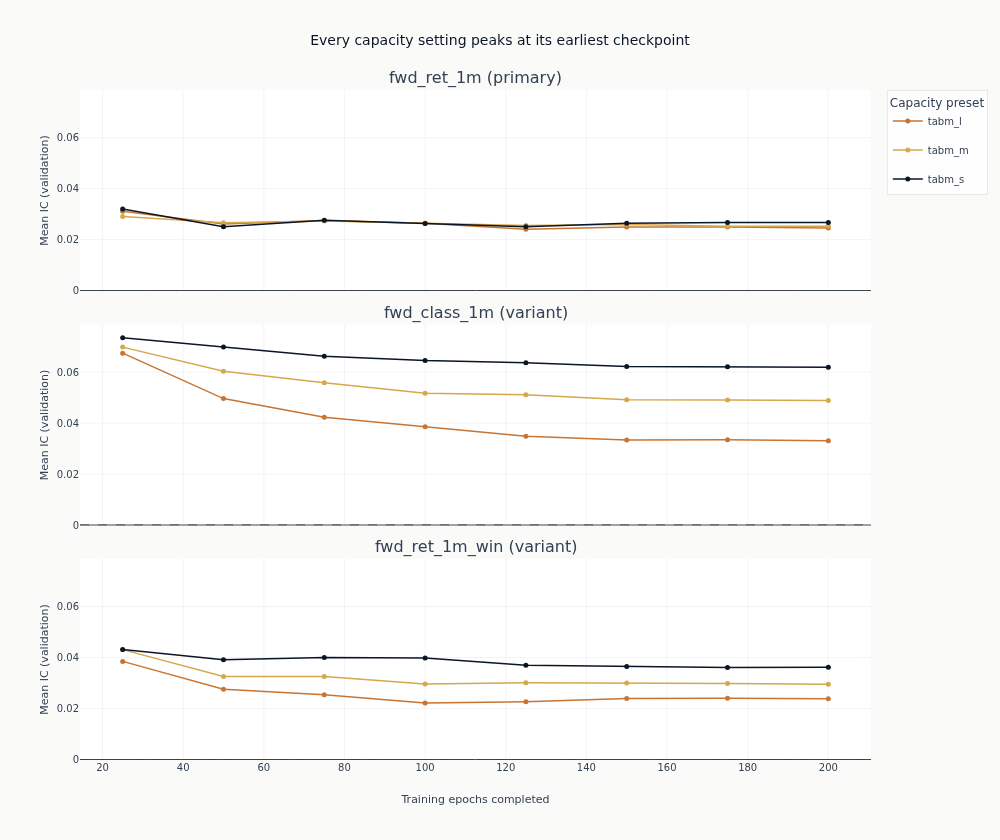

In [13]:
curves = catalog.filter("full_coverage").sort("label", "config_name", "checkpoint_value")
capacities = {
    "tabm_s": COLORS["blue"],
    "tabm_m": COLORS["amber"],
    "tabm_l": COLORS["copper"],
}


def capacity_color(name: str) -> str:
    """Return the declared preset's colour, refusing a name the palette does not cover.

    Defaulting would draw an unlisted preset in another one's colour under a legend saying the
    colour is the capacity setting, which is the one thing the figure claims.
    """
    try:
        return capacities[name]
    except KeyError as error:
        raise ValueError(f"{name!r} is not a declared TabM preset: {sorted(capacities)}") from error


# `shared_yaxes` matches axes across columns, so with one column it does nothing and each panel
# would be rescaled to fill itself. Matching every row to the first is what puts the targets on
# one vertical scale, which is what stacking them is for.
fig_curves = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
drawn: set[str] = set()
for row, label in enumerate(panel_labels, start=1):
    panel = curves.filter(pl.col("label") == label)
    for config_name in panel.get_column("config_name").unique(maintain_order=True):
        series = panel.filter(pl.col("config_name") == config_name).sort("checkpoint_value")
        fig_curves.add_trace(
            go.Scatter(
                x=series.get_column("checkpoint_value").to_list(),
                y=series.get_column("ic_mean").to_list(),
                mode="lines+markers",
                name=config_name,
                legendgroup=config_name,
                showlegend=config_name not in drawn,
                line=dict(color=capacity_color(config_name), width=1.5),
                marker=dict(size=5),
            ),
            row=row,
            col=1,
        )
        drawn.add(config_name)
    fig_curves.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_curves.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
    if row > 1:
        fig_curves.update_yaxes(matches="y", row=row, col=1)
fig_curves.update_xaxes(title_text="Training epochs completed", row=len(panel_labels), col=1)
fig_curves.update_layout(
    title="Every capacity setting peaks at its earliest checkpoint",
    height=280 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    legend=dict(title_text="Capacity preset"),
)
# Where the lines peak is a fact about the frame, so the alt text counts it rather than asserting
# a shape the next run may not reproduce.
peaks = (
    curves.group_by("label", "config_name")
    .agg(
        peak_checkpoint=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
        first_checkpoint=pl.col("checkpoint_value").min(),
        last_checkpoint=pl.col("checkpoint_value").max(),
    )
    .with_columns(
        peaks_at_the_start=pl.col("peak_checkpoint") == pl.col("first_checkpoint"),
        peaks_at_the_end=pl.col("peak_checkpoint") == pl.col("last_checkpoint"),
    )
)
peak_text = "; ".join(
    f"{row['label']}: {row['at_start']} of {row['total']} at the first checkpoint and "
    f"{row['at_end']} at the last"
    for row in peaks.group_by("label")
    .agg(
        total=pl.len(),
        at_start=pl.col("peaks_at_the_start").sum(),
        at_end=pl.col("peaks_at_the_end").sum(),
    )
    .sort("label")
    .iter_rows(named=True)
)
show_plotly_with_alt(
    fig_curves,
    "Line charts of mean validation information coefficient against the number of training epochs "
    "completed, one line per capacity preset - dark navy for tabm_s, gold for tabm_m, copper for "
    "tabm_l - with a marker at each declared epoch checkpoint. One panel per label on one shared "
    "pair of axes, each with a dashed zero line. Counted from the frame, the configurations whose "
    f"highest point is their first checkpoint against their last are {peak_text}.",
)

### Whether capacity is what separates them

The chart below drops the checkpoint dimension twice over, once at each end. The left bar of
each pair is a configuration's IC at its first checkpoint and the right bar is its IC at its
last, so every configuration is compared at the same two amounts of training and the gap between
the pair is what the remaining epochs bought. Comparing capacity at a stopping point chosen
after the fact would compare three configurations at three different training lengths.

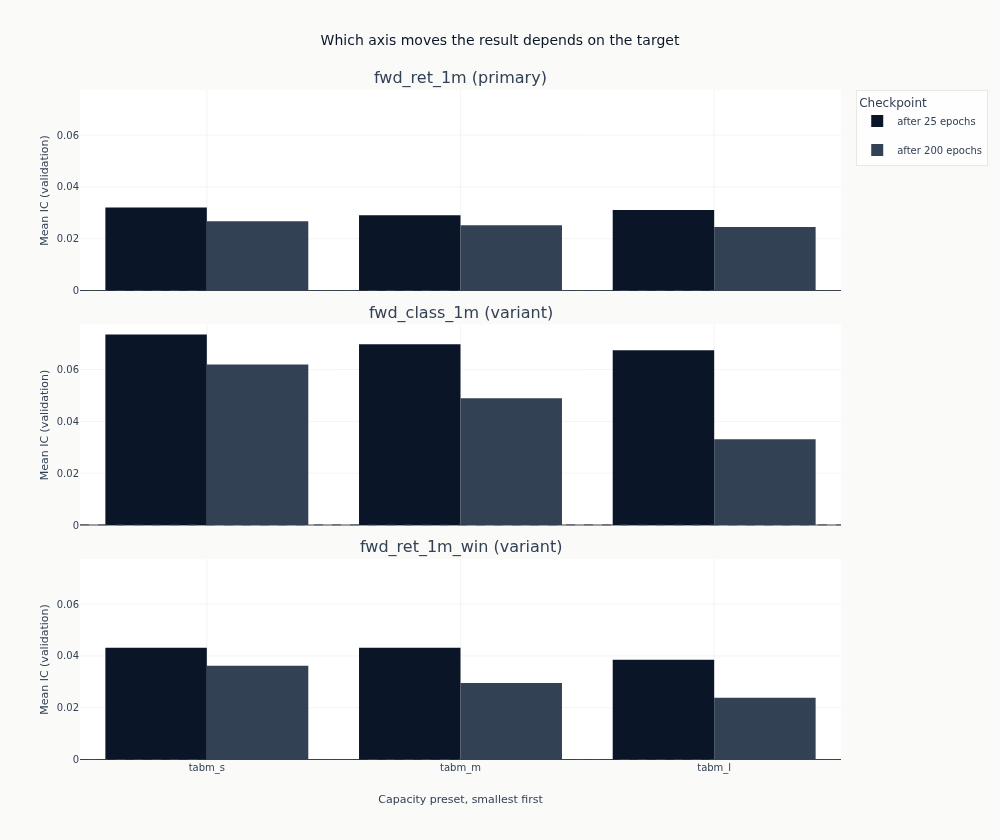

In [14]:
edges = (
    curves.group_by("label", "config_name")
    .agg(
        first_ic=pl.col("ic_mean").sort_by("checkpoint_value").first(),
        last_ic=pl.col("ic_mean").sort_by("checkpoint_value").last(),
        first_checkpoint=pl.col("checkpoint_value").min(),
        last_checkpoint=pl.col("checkpoint_value").max(),
    )
    .sort("label", "config_name")
)
first_epoch = int(edges.get_column("first_checkpoint").max())
last_epoch = int(edges.get_column("last_checkpoint").max())

fig_capacity = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = edges.filter(pl.col("label") == label)
    order = [name for name in capacities if name in set(panel.get_column("config_name"))]
    panel = panel.with_columns(
        rank=pl.col("config_name").replace_strict(
            {name: index for index, name in enumerate(order)}, return_dtype=pl.Int32
        )
    ).sort("rank")
    for column, color, legend in (
        ("first_ic", COLORS["blue"], f"after {first_epoch} epochs"),
        ("last_ic", COLORS["neutral"], f"after {last_epoch} epochs"),
    ):
        fig_capacity.add_trace(
            go.Bar(
                x=panel.get_column("config_name").to_list(),
                y=panel.get_column(column).to_list(),
                marker_color=color,
                name=legend,
                legendgroup=legend,
                showlegend=row == 1,
            ),
            row=row,
            col=1,
        )
    fig_capacity.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_capacity.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
    if row > 1:
        fig_capacity.update_yaxes(matches="y", row=row, col=1)
fig_capacity.update_xaxes(
    title_text="Capacity preset, smallest first", row=len(panel_labels), col=1
)
fig_capacity.update_layout(
    title="Which axis moves the result depends on the target",
    height=280 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    barmode="group",
    legend=dict(title_text="Checkpoint"),
)
# Whether the gap within a pair beats the gap across presets is what the chart is for, and it
# differs by label, so the alt reads it rather than asserting one answer for all three.
within = (
    edges.with_columns(pair_gap=(pl.col("first_ic") - pl.col("last_ic")).abs())
    .group_by("label")
    .agg(
        median_pair_gap=pl.col("pair_gap").median(),
        across_presets=pl.col("last_ic").max() - pl.col("last_ic").min(),
    )
    .sort("label")
)
gap_text = "; ".join(
    f"{row['label']}: {'wider' if row['median_pair_gap'] > row['across_presets'] else 'narrower'}"
    for row in within.iter_rows(named=True)
)
show_plotly_with_alt(
    fig_capacity,
    "Grouped bar charts of mean validation information coefficient, one pair of bars per capacity "
    f"preset: dark navy for the first checkpoint at {first_epoch} epochs and neutral grey for the "
    f"last at {last_epoch}. One panel per label on one shared vertical scale, presets ordered "
    "smallest to largest, each panel carrying a dashed zero line. Counted from the frame, the "
    "median across presets of the gap between a preset's two bars, set against the spread across "
    f"presets at the last checkpoint, is {gap_text}. It is a median, so a single preset can run "
    "against the label's direction.",
)

The frame below is the claim the two charts make, computed rather than read off them. For each
target it puts the range the checkpoint covers within a configuration against the range capacity
covers across the grid at a fixed amount of training. Both are computed inside a target, because
comparing a within-run range against a spread taken across targets would compare two different
things.

In [15]:
checkpoint_vs_capacity = (
    curves.group_by("label", "config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .group_by("label")
    .agg(median_checkpoint_range=pl.col("checkpoint_range").median())
    .join(
        edges.group_by("label").agg(
            across_capacity_first=pl.col("first_ic").max() - pl.col("first_ic").min(),
            across_capacity_last=pl.col("last_ic").max() - pl.col("last_ic").min(),
        ),
        on="label",
    )
    .with_columns(
        checkpoint_dominates=pl.col("median_checkpoint_range")
        > pl.max_horizontal("across_capacity_first", "across_capacity_last")
    )
    .sort("label")
)
print(f"capacity compared at {first_epoch} and at {last_epoch} epochs")
checkpoint_vs_capacity

capacity compared at 25 and at 200 epochs


label,median_checkpoint_range,across_capacity_first,across_capacity_last,checkpoint_dominates
str,f64,f64,f64,bool
"""fwd_class_1m""",0.020908,0.006086,0.028845,false
"""fwd_ret_1m""",0.006967,0.002966,0.002145,true
"""fwd_ret_1m_win""",0.013631,0.004638,0.012342,true


## 5. What to notice

**The objective is fixed here, and it is the one [`06_gbm`](06_gbm.ipynb) identified as the
poorly matched one.** The shared runner minimizes squared error on a regression target, and the
menu offers no alternative. That is a property of the implementation rather than a finding about
TabM: a loss that weights an observation by the square of its error can be replaced, and the
reason this notebook does not replace it is that doing so would change what the book's published
TabM population is. Read the learning curves with that in mind - they are the behaviour of one
objective at three capacities, not of the architecture in general.

**The checkpoint is where the training length becomes visible, and it is registered rather than
resolved.** A single end-of-training number cannot distinguish a configuration that converged
from one that peaked early and decayed, and `checkpoint_vs_capacity` says which of the two axes
moves the result further on each target. Where the checkpoint range exceeds the capacity spread,
a comparison of the three presets at a stopping point chosen after the fact would be reporting
where each training run happened to be rather than what its capacity bought.

**The two regression targets are a controlled test of the same diagnosis.** `fwd_ret_1m_win` is
`fwd_ret_1m` with each month's cross-section clipped at its own tails. If the extremes are what
steers a squared-error fit away from the ranking, clipping them should change the shape of the
curves rather than merely shifting them, and that is a directional prediction about two panels of
the same figure - available only because one run fitted both.

**The classification target is on a different objective entirely.** Cross-entropy on
`fwd_class_1m` has no stake in how large a return was, only in which side of the cut it fell.
`by_label` puts it on the same IC axis as the other two through the continuous return it was cut
from, and on the same AUC axis as `fwd_ret_1m` through the direction sibling that label declares.

**None of this selects anything.** IC measures whether predictions rank firms correctly, not
whether a strategy trading them makes money after costs and turnover, and every checkpoint of
every configuration stays in the published population for that reason. Selection is on validation
backtest Sharpe in [`11_backtest`](11_backtest.ipynb), where the checkpoint is part of what is
selected.

**Known limitations.** The IC is an average of monthly rank correlations with no adjustment for
serial dependence, so it is a diagnostic rather than a test, and it carries no interval that
would say whether two presets differ. The grid varies capacity at a fixed dropout, a fixed
learning-rate schedule and a fixed epoch budget, so it says nothing about what a tuned network
would do - and the epoch budget is the one of those the curves let you see the cost of. Fold
preprocessing imputes missing characteristics at the training fold's median, which is a value
nobody observed, and the trees in [`06_gbm`](06_gbm.ipynb) did not need it. And every number is
measured on validation folds that have been read many times over by the time a case study
reaches this notebook.

**Next**: [`08_latent_factors`](08_latent_factors.ipynb) stops predicting the return directly and
asks what small set of factors the 57 characteristics describe, then whether exposures to those
factors carry the signal that the models fitted to the characteristics themselves have been
looking for.